In [1]:
#@title << Run this cell first — environment setup {display-mode: "form"}
import sys, os

if "google.colab" in sys.modules:
    !git clone --quiet --single-branch --branch main https://github.com/YanickSchraner/CAS-DeepRL.git
    !cp -r "CAS-DeepRL/Tag 1/envs" .
    sys.path.insert(0, ".")
else:
    sys.path.insert(0, os.getcwd())

> 📝 **Homework** — Complete this notebook before Day 2. It applies the Q-Learning you coded in class to a real business problem and sets up the RL Engineer mindset for tomorrow.

# Challenge: Q-Learning for Inventory Management 📦

## The Business Problem

You just coded Q-Learning from scratch on FrozenLake (navigation) and Taxi-v3 (routing). Now you'll apply the **exact same algorithm** to a real business problem: **inventory management**.

**The setting:** You run a small warehouse. Each day you decide how many units to reorder. Your orders arrive the next morning (1-day lead time). Demand is stochastic — higher on weekends. You pay holding costs for excess stock and take a hit when you run out.

**Real-world analogs:**
- **Amazon** uses ML-assisted replenishment for millions of SKUs
- **Zalando** predicted demand and reduced stockouts by ~20% with RL-based ordering
- **Zara** built its famous fast-fashion model partly on supply-chain optimization

The traditional solution is the **Economic Order Quantity (EOQ)** model and reorder-point rules. But these struggle when demand patterns are complex. RL can learn a better policy from experience.

## Your Mission

You already know Q-Learning. The challenge here is:
1. Apply it to a new environment (not a toy grid)
2. Understand what the state, action, and reward represent in business terms
3. Beat the rule-based baseline (the traditional approach)
4. Investigate the effect of reward design on agent behaviour

## Setup

In [2]:
!pip install gymnasium numpy matplotlib --quiet

In [3]:
import sys, os

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from envs.inventory_env import InventoryEnv, DiscreteInventoryEnv

## Part 1 — Understand the Environment

Before writing any learning code, understand the **five MDP components** in business terms.

---

### The Environment

You manage a small warehouse selling a single product. Each morning customers arrive and purchase as many units as are in stock. Demand is **stochastic** — drawn from a normal distribution centred around 12 units/day, with a +5 unit boost on Saturdays and Sundays. Orders placed today arrive the **next morning** (lead time = 1 day), so you must anticipate demand one day ahead.

---

### Observation Space — what the agent sees each day

| Signal | Range | Business meaning |
|---|---|---|
| `stock_norm` | [0, 1] | Current inventory as a fraction of the warehouse capacity (100 units) |
| `pending_norm` | [0, 1] | Quantity on order arriving tomorrow, normalised by the maximum single order (30 units) |
| `demand_norm` | [0, 1] | Yesterday's realised demand, normalised by the demand ceiling (25 units) |
| `day_sin` | [-1, 1] | Sine-encoded day of week — lets the agent distinguish weekdays from weekends without a discontinuity at Sunday→Monday |

For Q-Learning, `DiscreteInventoryEnv` converts these 4 continuous signals into a **single integer** (0–349) by binning each dimension. This is the `DiscreteInventoryEnv` you will use below.

---

### Actions — what the agent decides each day

The agent chooses one replenishment order per day from 7 options:

| Action index | Order qty | When to use |
|---|---|---|
| 0 | 0 units | Stock is sufficient; avoid paying the €20 fixed order cost |
| 1 | 5 units | Small top-up |
| 2 | 10 units | Moderate replenishment |
| 3 | 15 units | Standard order |
| 4 | 20 units | Large order |
| 5 | 25 units | Very large order |
| 6 | 30 units | Maximum order — pre-stocking before high-demand days |

Ordered units arrive the **next day**. Ordering too often wastes the €20 fixed cost; ordering too little risks a stockout.

---

### Reward Signal — what we optimise

The daily reward encodes the warehouse P&L:

```
reward = revenue − holding_cost − stockout_penalty − order_fixed_cost
```

| Component | Formula | Business intuition |
|---|---|---|
| Revenue | units_sold × €50 | Earn €50 per unit sold |
| Holding cost | end-of-day stock × €1 | Storing unsold inventory ties up capital |
| Stockout penalty | unmet demand × €30 | Lost sale plus reputational damage |
| Order fixed cost | €20 if order > 0 | Logistics cost per delivery, regardless of quantity |

**Key tension:** to earn revenue you need stock, but stock costs money to hold. Placing frequent small orders is expensive; placing infrequent large orders risks either overstocking or stockouts. The agent must learn to **batch orders and anticipate weekend demand spikes**.

---

### Episode — how long does one run last?

One episode = **30 consecutive days**. The warehouse starts each episode with a random initial stock between 20 and 60 units. The episode ends after day 30; there is no early termination. The agent's goal is to maximise total reward accumulated over the full 30-day period.

In [4]:
# Explore the continuous version first (for intuition)
env_cont = InventoryEnv(seed=42)
print("=== InventoryEnv (continuous obs) ===")
print(f"Obs space   : {env_cont.observation_space}")
print(f"  -> [stock/100, pending/30, last_demand/25, sin(dow)]")
print(f"Action space: {env_cont.action_space}")
print(f"  -> order quantities: {env_cont.ORDER_QUANTITIES} units")
print()

# Explore the discrete version (for Q-Learning)
env = DiscreteInventoryEnv(seed=42)
print("=== DiscreteInventoryEnv (tabular Q-Learning) ===")
print(f"Obs space   : {env.observation_space}  ({env.N_STATES} discrete states)")
print(f"  -> stock (5 bins) x pending (7) x demand (5 bins) x dow (2) = {env.N_STATES}")
print(f"Action space: {env.action_space}")
print()

# Show one sample
state, _ = env.reset(seed=42)
print(f"Starting state (integer): {state}")
print(f"  -> stock={env._stock}, pending={env._pending}, last_demand={env._last_demand}, dow={env._dow}")

=== InventoryEnv (continuous obs) ===
Obs space   : Box([ 0.  0.  0. -1.], 1.0, (4,), float32)
  -> [stock/100, pending/30, last_demand/25, sin(dow)]
Action space: Discrete(7)
  -> order quantities: [0, 5, 10, 15, 20, 25, 30] units

=== DiscreteInventoryEnv (tabular Q-Learning) ===
Obs space   : Discrete(350)  (350 discrete states)
  -> stock (5 bins) x pending (7) x demand (5 bins) x dow (2) = 350
Action space: Discrete(7)

Starting state (integer): 71
  -> stock=23, pending=0, last_demand=12, dow=0


> ❓ **Before you run the next cells:** Given the observation space and reward signal above, what ordering strategy would *you* use? When would you order more — before a weekend or after? How much safety stock would you keep?

Write down your intuition. After training you'll compare it to what the agent discovered.

## Part 2 — Build the Baselines

In real operations, inventory is managed with **rule-based policies**. We need to beat these to justify using RL.

In [5]:
def run_episodes(policy_fn, n_episodes=200, seed=0):
    """Run n_episodes with a given policy function and return mean/std reward."""
    rewards = []
    for ep in range(n_episodes):
        env = DiscreteInventoryEnv(seed=seed + ep)
        state, _ = env.reset()
        total, done = 0.0, False
        while not done:
            action = policy_fn(state, env)
            state, r, term, trunc, _ = env.step(action)
            total += r
            done = term or trunc
        rewards.append(total)
    return np.mean(rewards), np.std(rewards)


def random_policy(state, env):
    return env.action_space.sample()


def fixed_order_policy(qty_index):
    """Always order the same fixed quantity (classic s,S rule simplification)."""
    def policy(state, env):
        return qty_index
    return policy


def reorder_point_policy(state, env):
    """
    Classic reorder-point heuristic:
    - If stock is low, order a fixed batch
    - Otherwise do nothing
    Rule: order 20 units when stock falls below 30 units
    """
    # Decode approximate stock from state
    stock_bin = state % env.N_STOCK
    approx_stock = stock_bin * 20 + 10  # midpoint of bin
    if approx_stock < 30:   # below reorder point
        return 4            # order 20 units (index 4)
    return 0                # order nothing


print("Computing baseline performance (200 episodes each)...")
baselines = {
    "Random"         : run_episodes(random_policy),
    "Always order 0" : run_episodes(fixed_order_policy(0)),
    "Always order 15": run_episodes(fixed_order_policy(3)),
    "Always order 20": run_episodes(fixed_order_policy(4)),
    "Reorder-point"  : run_episodes(reorder_point_policy),
}

print("\nBaseline comparison (mean reward over 30-day episode):")
print("-" * 50)
for name, (mean, std) in baselines.items():
    print(f"  {name:<20}: {mean:8.1f} ± {std:.0f}")

Computing baseline performance (200 episodes each)...

Baseline comparison (mean reward over 30-day episode):
--------------------------------------------------
  Random              :  16687.9 ± 1327
  Always order 0      :  -8349.5 ± 1099
  Always order 15     :  16896.5 ± 1346
  Always order 20     :  16307.8 ± 1120
  Reorder-point       :  17000.5 ± 1134


❓ **Before training:** Which baseline do you expect Q-Learning to beat? Why does 'Always order 0' perform differently from 'Random'?

## Part 3 — Train Q-Learning on InventoryEnv

The Q-Learning algorithm is **identical** to what you used on FrozenLake. Only the environment changes. This is the power of the MDP abstraction.

In [6]:
# Q-Learning — same implementation as FrozenLake/Taxi, different environment

def initialize_q_table(n_states, n_actions):
    return np.zeros((n_states, n_actions))


def epsilon_greedy(Q, state, epsilon, n_actions):
    if np.random.random() > epsilon:
        return int(np.argmax(Q[state]))
    return np.random.randint(n_actions)


def train_q_learning(
    n_episodes=10_000,
    learning_rate=0.3,
    gamma=0.95,
    max_epsilon=1.0,
    min_epsilon=0.05,
    decay_rate=0.001,
    seed=42,
):
    Q = initialize_q_table(DiscreteInventoryEnv.N_STATES, len(InventoryEnv.ORDER_QUANTITIES))
    rewards_per_episode = []

    for ep in tqdm(range(n_episodes), desc="Training"):
        epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * ep)
        env = DiscreteInventoryEnv(seed=seed + ep)
        state, _ = env.reset()
        total, done = 0.0, False

        while not done:
            action = epsilon_greedy(Q, state, epsilon, env.action_space.n)
            next_state, reward, term, trunc, _ = env.step(action)
            done = term or trunc

            # Bellman update
            Q[state][action] += learning_rate * (
                reward + gamma * np.max(Q[next_state]) - Q[state][action]
            )
            state = next_state
            total += reward

        rewards_per_episode.append(total)

    return Q, rewards_per_episode


Q_table, training_rewards = train_q_learning(n_episodes=10_000)
print("\nTraining complete.")
print(f"Q-table shape: {Q_table.shape}  ({Q_table.shape[0]} states × {Q_table.shape[1]} actions)")

Training: 100%|██████████| 10000/10000 [00:19<00:00, 520.27it/s]


Training complete.
Q-table shape: (350, 7)  (350 states × 7 actions)


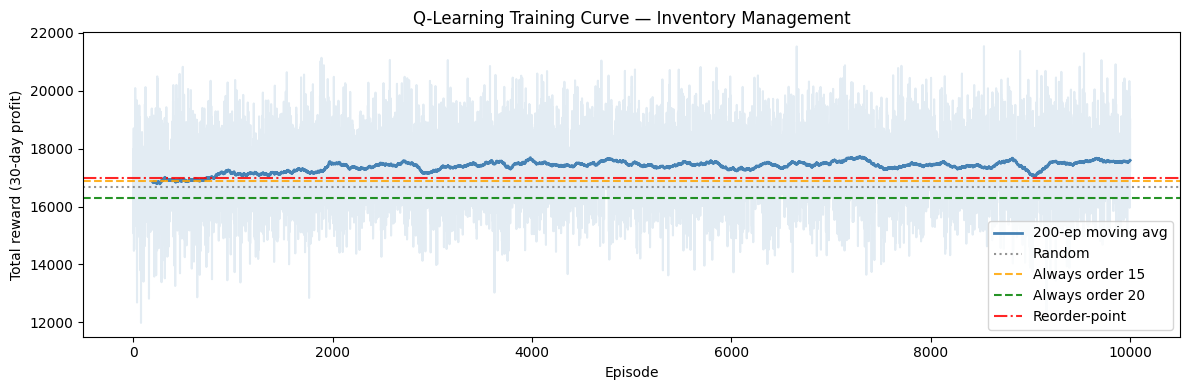

In [7]:
# Plot training curve
window = 200
smoothed = np.convolve(training_rewards, np.ones(window)/window, mode="valid")

EXCLUDE_FROM_PLOT = {"Always order 0"}  # too low to be informative
BASELINE_STYLE = {
    "Random":          {"color": "grey",   "linestyle": ":"},
    "Always order 15": {"color": "orange", "linestyle": "--"},
    "Always order 20": {"color": "green",  "linestyle": "--"},
    "Reorder-point":   {"color": "red",    "linestyle": "-."},
}

plt.figure(figsize=(12, 4))
plt.plot(training_rewards, alpha=0.15, color="steelblue")
plt.plot(range(window-1, len(training_rewards)), smoothed,
         color="steelblue", linewidth=2, label=f"{window}-ep moving avg")

for name, (m, _) in baselines.items():
    if name in EXCLUDE_FROM_PLOT:
        continue
    style = BASELINE_STYLE.get(name, {"color": "grey", "linestyle": "--"})
    plt.axhline(m, alpha=0.85, label=name, **style)

plt.xlabel("Episode")
plt.ylabel("Total reward (30-day profit)")
plt.title("Q-Learning Training Curve — Inventory Management")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [8]:
# Evaluate the trained Q-Learning agent
def q_policy(state, env):
    return int(np.argmax(Q_table[state]))

ql_mean, ql_std = run_episodes(q_policy, n_episodes=200)

print("Final evaluation (200 episodes):")
print("-" * 50)
for name, (m, s) in baselines.items():
    print(f"  {name:<20}: {m:8.1f} ± {s:.0f}")
print(f"  {'Q-Learning':<20}: {ql_mean:8.1f} ± {ql_std:.0f}  ← trained agent")
best_baseline = max(baselines.values(), key=lambda x: x[0])[0]
print(f"\n  Improvement vs best baseline: {ql_mean - best_baseline:.1f} ({(ql_mean - best_baseline)/abs(best_baseline)*100:.1f}%)")

Final evaluation (200 episodes):
--------------------------------------------------
  Random              :  16687.9 ± 1327
  Always order 0      :  -8349.5 ± 1099
  Always order 15     :  16896.5 ± 1346
  Always order 20     :  16307.8 ± 1120
  Reorder-point       :  17000.5 ± 1134
  Q-Learning          :  17435.1 ± 1147  ← trained agent

  Improvement vs best baseline: 434.7 (2.6%)


## Part 4 — Analyse the Learned Policy

What did the agent actually learn? Let's look at what it does in specific situations.

### How does the Q-table map states to actions?

Before inspecting the Q-table it helps to understand how `DiscreteInventoryEnv` encodes the world.

**The state encoding:** The 4-dimensional world is collapsed into a **single integer** using mixed-radix encoding — the same idea as packing a date into YYYYMMDD:

```
state = stock_bin  +  5 × pending_bin  +  35 × demand_bin  +  175 × dow_bin
```

where:
- `stock_bin` ∈ {0–4} — which 20-unit bucket the inventory falls in (0–19 | 20–39 | 40–59 | 60–79 | 80+)
- `pending_bin` ∈ {0–6} — which order quantity is in transit (matches the 7 `ORDER_QUANTITIES`)
- `demand_bin` ∈ {0–4} — which 5-unit bucket yesterday's demand fell in
- `dow_bin` ∈ {0, 1} — weekday (0) or weekend (1)

This gives 5 × 7 × 5 × 2 = **350 unique states**, each a row in the Q-table. The Q-table is simply a **350 × 7 array** indexed directly by this integer — no computation needed at lookup time.

**Why this works here — and where it breaks down:** The encoding works because the state space is small and hand-crafted. Real inventory systems have continuous demand signals, supplier lead times, and dozens of SKUs. Discretising them produces billions of states — the table explodes. That is exactly when you replace the table with a **neural network** approximating Q(s, a). That's DQN, and it's what Day 2 covers.

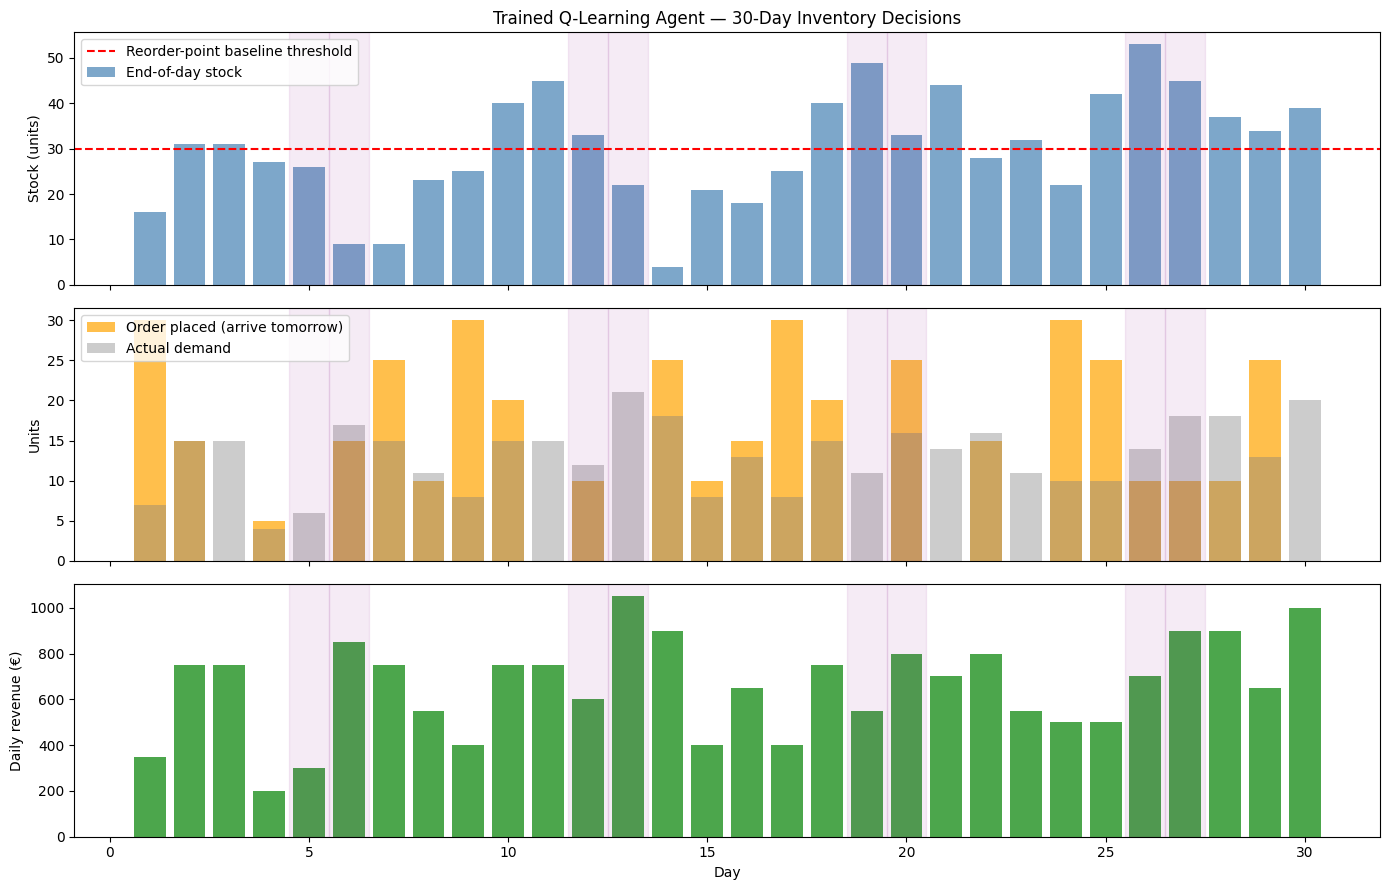

Purple bands = weekends (higher demand)
Stockouts: 3 days had a stockout


In [9]:
# Run one episode and visualise the agent's decisions
env_vis = DiscreteInventoryEnv(seed=42)
state, _ = env_vis.reset()

days, stocks, orders, demands, revenues = [], [], [], [], []
done = False

while not done:
    action = int(np.argmax(Q_table[state]))
    order_qty = InventoryEnv.ORDER_QUANTITIES[action]
    state, _, term, trunc, info = env_vis.step(action)
    done = term or trunc
    days.append(env_vis._day)
    stocks.append(info["stock"])
    orders.append(order_qty)
    demands.append(info["demand"])
    revenues.append(info["revenue"])

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].bar(days, stocks, color="steelblue", alpha=0.7, label="End-of-day stock")
axes[0].axhline(30, color="red", linestyle="--", label="Reorder-point baseline threshold")
axes[0].set_ylabel("Stock (units)")
axes[0].legend()
axes[0].set_title("Trained Q-Learning Agent — 30-Day Inventory Decisions")

axes[1].bar(days, orders, color="orange", alpha=0.7, label="Order placed (arrive tomorrow)")
axes[1].bar(days, demands, color="grey", alpha=0.4, label="Actual demand")
axes[1].set_ylabel("Units")
axes[1].legend()

axes[2].bar(days, revenues, color="green", alpha=0.7)
axes[2].set_ylabel("Daily revenue (€)")
axes[2].set_xlabel("Day")

# Highlight weekends
for ax in axes:
    for d in days:
        if (d % 7) in [5, 6]:  # Sat and Sun
            ax.axvspan(d - 0.5, d + 0.5, alpha=0.08, color="purple")

plt.tight_layout()
plt.show()

print("Purple bands = weekends (higher demand)")
print(f"Stockouts: {sum(1 for i, d in enumerate(demands) if d > stocks[i])} days had a stockout")


In [10]:
# Inspect Q-table: what does the agent prefer in specific states?
print("What does the agent order in each stock situation?")
print("(showing most common action for each stock level, averaged over pending/demand/dow)")
print()

stock_labels = ["Very low (0-19)", "Low (20-39)", "Medium (40-59)", "High (60-79)", "Very high (80+)"]

for stock_bin in range(DiscreteInventoryEnv.N_STOCK):
    # Average Q-values over all states with this stock_bin
    states_with_this_stock = [
        s for s in range(DiscreteInventoryEnv.N_STATES)
        if s % DiscreteInventoryEnv.N_STOCK == stock_bin
    ]
    avg_q = Q_table[states_with_this_stock].mean(axis=0)
    best_action_idx = int(np.argmax(avg_q))
    best_order = InventoryEnv.ORDER_QUANTITIES[best_action_idx]
    print(f"  Stock {stock_labels[stock_bin]:<25}: usually orders {best_order:2d} units")

What does the agent order in each stock situation?
(showing most common action for each stock level, averaged over pending/demand/dow)

  Stock Very low (0-19)          : usually orders 30 units
  Stock Low (20-39)              : usually orders 30 units
  Stock Medium (40-59)           : usually orders  0 units
  Stock High (60-79)             : usually orders  0 units
  Stock Very high (80+)          : usually orders 10 units


❓ **Discussion:**
1. Does the agent's ordering pattern make intuitive sense? When stock is high, does it order less?
2. Does the agent pre-order before weekends? (It should, since demand is higher)
3. Where does Q-Learning outperform the reorder-point heuristic? Where does it still struggle?

## Part 5 — Reward Shaping Challenge 🎯

The default reward is:
```
reward = revenue - holding_cost - stockout_penalty - order_fixed_cost
```

**Business scenario:** Your manager says: *"We're losing customers every time we stock out — it's not just one lost sale, it's a customer who never comes back. Increase the stockout penalty significantly."*

**Task:** Create a modified version of `DiscreteInventoryEnv` that has a **higher stockout penalty** (e.g., 3× the current value). Train a new Q-Learning agent and compare:
1. Does the higher penalty reduce stockouts?
2. What is the trade-off (more stock held → higher holding costs)?
3. Does the total reward increase or decrease?

In [11]:
class HighStockoutPenaltyEnv(DiscreteInventoryEnv):
    # TODO: Override STOCKOUT_COST to be 3x higher
    # Hint: just set the class attribute
    pass


# --- Your code below ---
# Train Q-Learning on HighStockoutPenaltyEnv
# Compare stockout frequency vs. the original agent
# Compare holding costs vs. the original agent

In [12]:
#@title Example Solution (click ▶ to expand) {display-mode: "form"}

class HighStockoutPenaltyEnv(DiscreteInventoryEnv):
    STOCKOUT_COST = DiscreteInventoryEnv.STOCKOUT_COST * 3  # 90 €/unit instead of 30


def count_stockout_days(policy_fn, n_episodes=100, seed=100):
    """Count average number of days per episode where demand exceeded stock."""
    total = 0
    for ep in range(n_episodes):
        env = DiscreteInventoryEnv(seed=seed + ep)
        state, _ = env.reset()
        done = False
        while not done:
            action = policy_fn(state, env)
            state, _, term, trunc, info = env.step(action)
            done = term or trunc
            if info["unmet_demand"] > 0:
                total += 1
    return total / n_episodes


print("Training high-penalty agent (same hyperparams)...")
Q_penalty, _ = train_q_learning(n_episodes=10_000, learning_rate=0.3, gamma=0.95, seed=42)

def q_penalty_policy(state, env):
    return int(np.argmax(Q_penalty[state]))

orig_mean, orig_std = run_episodes(q_policy, n_episodes=200)
pen_mean,  pen_std  = run_episodes(q_penalty_policy, n_episodes=200)
orig_so = count_stockout_days(q_policy)
pen_so  = count_stockout_days(q_penalty_policy)

print(f"  Original          : reward={orig_mean:.1f}  stockout days/ep={orig_so:.1f}")
print(f"  High-penalty (3x) : reward={pen_mean:.1f}  stockout days/ep={pen_so:.1f}")
print()
print("Key insight: the high-penalty agent holds more safety stock,")
print("reducing stockouts at the cost of higher holding costs.")
print("Total reward may be lower — but that is the business trade-off.")

Training high-penalty agent (same hyperparams)...


Training: 100%|██████████| 10000/10000 [00:14<00:00, 693.04it/s]


  Original          : reward=17435.1  stockout days/ep=0.1
  High-penalty (3x) : reward=17129.9  stockout days/ep=0.0

Key insight: the high-penalty agent holds more safety stock,
reducing stockouts at the cost of higher holding costs.
Total reward may be lower — but that is the business trade-off.


## Part 6 — Hyperparameter Investigation

**Task:** Investigate the effect of `learning_rate` on training speed and final performance.

Train three agents with `learning_rate` ∈ {0.05, 0.3, 0.7} and plot their training curves on the same graph. Answer:
1. Which learns fastest (fewest episodes to reach baseline performance)?
2. Which reaches the highest final performance?
3. What's the risk of `learning_rate = 0.7` in a noisy environment?

Training with lr=0.05...


Training: 100%|██████████| 5000/5000 [00:07<00:00, 634.77it/s]


Training with lr=0.3...


Training: 100%|██████████| 5000/5000 [00:07<00:00, 643.02it/s]


Training with lr=0.7...


Training: 100%|██████████| 5000/5000 [00:07<00:00, 706.32it/s]


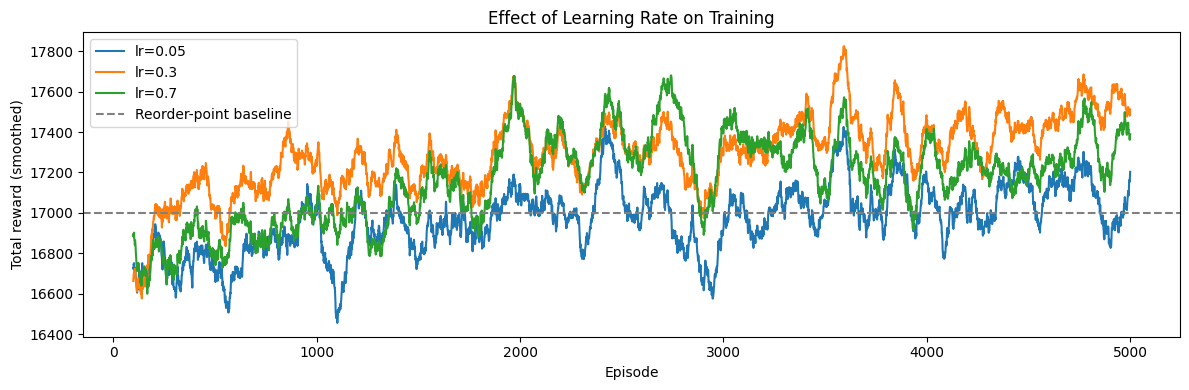

In [13]:
learning_rates = [0.05, 0.3, 0.7]
results = {}

for lr in learning_rates:
    print(f"Training with lr={lr}...")
    Q, rewards = train_q_learning(n_episodes=5_000, learning_rate=lr, seed=42)
    results[lr] = (Q, rewards)

window = 100
plt.figure(figsize=(12, 4))
for lr, (Q, rewards) in results.items():
    smoothed = np.convolve(rewards, np.ones(window)/window, mode="valid")
    plt.plot(range(window-1, len(rewards)), smoothed, label=f"lr={lr}")

plt.axhline(baselines["Reorder-point"][0], linestyle="--", color="grey", label="Reorder-point baseline")
plt.xlabel("Episode")
plt.ylabel("Total reward (smoothed)")
plt.title("Effect of Learning Rate on Training")
plt.legend()
plt.tight_layout()
plt.show()

## Summary

You applied Q-Learning — the same algorithm from FrozenLake — to a real business problem. The MDP abstraction is powerful: **once you frame a problem as (state, action, reward, transitions), the algorithm doesn't care whether it's a game or a warehouse**.

| What you did | Takeaway |
|---|---|
| Applied Q-Learning to InventoryEnv | The Bellman equation works on any MDP |
| Built baselines first | Rule-based policies are your competition |
| Analysed the learned policy | Interpretable policies build stakeholder trust |
| Modified the reward | Reward design = encoding business objectives |
| Swept learning rates | Hyperparameter sensitivity analysis |

**Key insight for Day 2:** Tabular Q-Learning works here because we have 350 discrete states. If the state space were continuous (stock level to 2 decimal places, real-time demand signals), we'd need a neural network — that's DQN and the policy gradient methods.